**CMD with RC selection box; M67 targets and isochrone backplotted (Reyes 2024)**

Launching Gaia query for M67 FLAME radii...
INFO: Query finished. [astroquery.utils.tap.core]
Retrieved 1418 stars with FLAME radii
M67 stars (quality cut): 1418


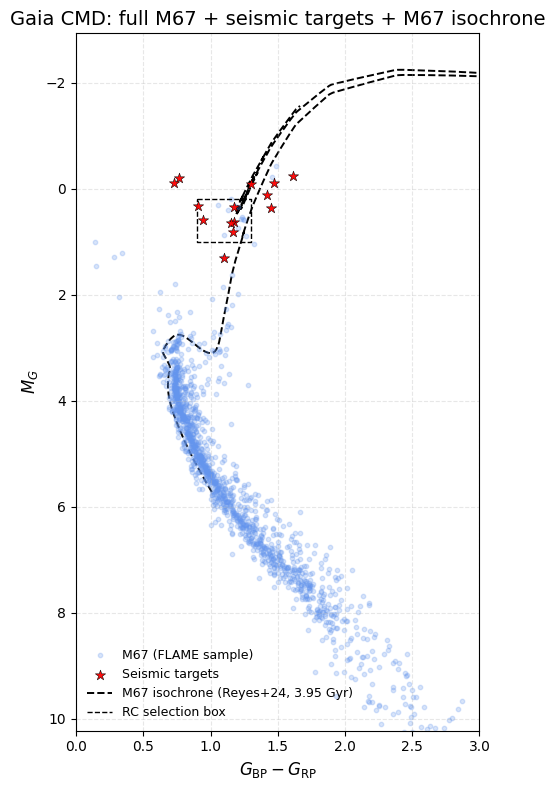

Saved visuals/CMD_RC_box_with_M67_isochrone_FULL.png


In [20]:
# files you will need: 
# M67combo.fits (Credit Jamie Tayar)
# M67_KHfit_try2.csv (Credit Jamie Tayar)
# ISOA.csv (Credit Jamie Tayar)
# wherever your data lives

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from astroquery.gaia import Gaia
from astropy.table import Table


# Query for M67
def query_m67_flame(radius_deg=0.5):
    ra_center, dec_center = 132.825, 11.80  # M67

    query = f"""
    SELECT
        g.source_id,
        g.parallax,
        g.parallax_error,
        g.phot_g_mean_mag,
        g.phot_bp_mean_mag,
        g.phot_rp_mean_mag,
        g.ruwe,
        a.radius_flame
    FROM gaiadr3.gaia_source AS g
    JOIN gaiadr3.astrophysical_parameters AS a
      ON g.source_id = a.source_id
    WHERE
        1 = CONTAINS(
            POINT('ICRS', g.ra, g.dec),
            CIRCLE('ICRS', {ra_center}, {dec_center}, {radius_deg})
        )
        AND g.parallax > 0
        AND g.parallax/g.parallax_error > 10
        AND g.ruwe < 1.4
        AND a.radius_flame IS NOT NULL
    """

    print("Launching Gaia query for M67 FLAME radii...")
    job = Gaia.launch_job_async(query)
    result = job.get_results()
    print(f"Retrieved {len(result)} stars with FLAME radii")
    return result.to_pandas()

m67_df = query_m67_flame(radius_deg=0.5)

# CMD 
m67_parallax = np.array(m67_df["parallax"])
m67_dist_pc  = 1000.0 / m67_parallax
m67_MG       = m67_df["phot_g_mean_mag"] - 5 * np.log10(m67_dist_pc) + 5
m67_bp_rp    = m67_df["phot_bp_mean_mag"] - m67_df["phot_rp_mean_mag"]

m67_mask = np.isfinite(m67_bp_rp) & np.isfinite(m67_MG)
print(f"M67 stars (quality cut): {m67_mask.sum()}")

# your targets
df_t = pd.read_csv("master_all_clean_best_radius.csv")

bp = pd.to_numeric(df_t["bp_rp"], errors="coerce")
MG = pd.to_numeric(df_t["M_G"],   errors="coerce")

tic_col = next(
    c for c in ["TICID", "ticid", "TIC", "TIC_ID", "TIC Id", "TIC Id."]
    if c in df_t.columns
)
tic = df_t[tic_col].astype(str)

# rc box
RC_COLOR_MIN, RC_COLOR_MAX = 0.9, 1.3
RC_MG_MIN,   RC_MG_MAX   = 0.2, 1.0

in_rc = (
    (bp >= RC_COLOR_MIN) & (bp <= RC_COLOR_MAX) &
    (MG >= RC_MG_MIN)   & (MG <= RC_MG_MAX)
)

state = np.full(len(df_t), "RGB", dtype=object)
state[in_rc] = "RC"
df_t["evo_state"] = state

m_t = np.isfinite(bp) & np.isfinite(MG)
x, y, lab = bp[m_t], MG[m_t], state[m_t]

# Reyes (2024) isochrone
isoc = Table.read("ISOA.csv", format="ascii", delimiter=",")  # adjust path if needed
iso_color = np.array(isoc["abs_mag_bp_dr2"] - isoc["abs_mag_rp_dr2"], dtype=float)
iso_MG    = np.array(isoc["abs_mag_g_dr2"], dtype=float)

iso_color_shifted = iso_color + ISO_COLOR_SHIFT
iso_MG_shifted    = iso_MG    + ISO_MG_SHIFT

#plot
PLOT_SIZE = (5, 8)   
plt.figure(figsize=PLOT_SIZE)

# (a) Background: ALL M67 stars
plt.scatter(
    m67_bp_rp[m67_mask],
    m67_MG[m67_mask],
    s=10,
    alpha=0.25,
    color="cornflowerblue",
    label="M67 (FLAME sample)",
    zorder=1
)

# (b) Foreground: your seismic targets
plt.scatter(
    x,
    y,
    s=60,
    alpha=0.95,
    color="red",
    marker="*",
    edgecolors="black",
    linewidths=0.4,
    label="Seismic targets",
    zorder=3
)

# (c) Reyes (2024) isochrone
plt.plot(
    iso_color_shifted,
    iso_MG_shifted,
    linestyle="--",
    linewidth=1.4,
    color="black",
    label="M67 isochrone (Reyes+24, 3.95 Gyr)",
    zorder=0
)

# (d) RC selection box
rect_x = [RC_COLOR_MIN, RC_COLOR_MAX, RC_COLOR_MAX, RC_COLOR_MIN, RC_COLOR_MIN]
rect_y = [RC_MG_MIN,    RC_MG_MIN,    RC_MG_MAX,    RC_MG_MAX,    RC_MG_MIN]
plt.plot(rect_x, rect_y, linestyle="--", linewidth=1, color="black",
         label="RC selection box", zorder=2)

mg_all = np.concatenate([m67_MG[m67_mask], y])
mg_bright = np.nanmin(mg_all)
mg_faint  = np.nanmax(mg_all)

plt.ylim(mg_faint - 2, mg_bright - 2.5)  
plt.xlim(0, 3)

plt.xlabel(r"$G_{\rm BP} - G_{\rm RP}$", fontsize=12)
plt.ylabel(r"$M_G$", fontsize=12)
plt.title("Gaia CMD: full M67 + seismic targets + M67 isochrone", fontsize=14)
plt.legend(frameon=False, fontsize=9)
plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()

outdir = "visuals"
os.makedirs(outdir, exist_ok=True)
outfile = os.path.join(outdir, "CMD_RC_box_with_M67_isochrone_FULL.png")
plt.savefig(outfile, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved {outfile}")
